# Dyna-Q+ on Taxi-v3 with a dynamic environment change

The wrapper installs an extra wall: action 3 (west) at any state in row 2 is blocked
for the first 1000 real steps. After that the wall disappears and a shortcut opens.

- Dyna-Q's policy never re-tries (row 2, west) because Q is low
- Dyna-Q+'s κ√τ bonus eventually pushes the agent back, exposing the new shortcut


In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt


## Custom wrapper


In [2]:
class ChangingTaxi(gym.Wrapper):
    def __init__(self, env, T_change=1000):
        super().__init__(env)
        self.t = 0
        self.T_change = T_change

    def reset(self, **kw):
        return self.env.reset(**kw)

    def step(self, a):
        s = self.env.unwrapped.s
        row = (s // 100) // 5    # taxi row from Taxi-v3 state encoding
        if self.t <= self.T_change and a == 3 and row == 2:
            self.t += 1
            return s, -1, False, False, {}     # block west at row 2
        ns, r, term, trunc, info = self.env.step(a)
        self.t += 1
        return ns, r, term, trunc, info


## Algorithm (Dyna-Q+ flag toggles the κ√τ bonus)


In [3]:
def run(use_plus=False, max_steps=6000, n_planning=20, alpha=0.1,
        gamma=0.95, eps=0.05, kappa=0.05, seed=0):
    env = ChangingTaxi(gym.make("Taxi-v3"), T_change=1000)
    nS, nA = env.observation_space.n, env.action_space.n
    rng = np.random.default_rng(seed)

    Q = np.zeros((nS, nA))
    model = {}
    last_visit = np.zeros((nS, nA))
    rewards = np.zeros(max_steps)
    s, _ = env.reset(seed=seed)

    for t in range(max_steps):
        a = rng.integers(nA) if rng.random() < eps else int(np.argmax(Q[s]))
        ns, r, term, trunc, _ = env.step(a)
        target = r + (0 if term else gamma * Q[ns].max())
        Q[s, a] += alpha * (target - Q[s, a])
        model[(s, a)] = (r, ns)
        last_visit[s, a] = t

        if n_planning and model:
            keys = list(model.keys())
            idx = rng.integers(len(keys), size=n_planning)
            for k in idx:
                ps, pa = keys[k]
                pr, pns = model[(ps, pa)]
                bonus = kappa * np.sqrt(t - last_visit[ps, pa]) if use_plus else 0.0
                Q[ps, pa] += alpha * (pr + bonus + gamma * Q[pns].max() - Q[ps, pa])

        rewards[t] = r
        s, _ = env.reset() if (term or trunc) else (ns, None)

    env.close()
    return rewards


## Run Dyna-Q vs Dyna-Q+ (8 seeds each)


In [4]:
seeds = range(8)
dq = np.array([run(False, seed=s) for s in seeds])
dqp = np.array([run(True, seed=s) for s in seeds])

print(f"Dyna-Q  final cumulative: {np.cumsum(dq.mean(0))[-1]:.0f}")
print(f"Dyna-Q+ final cumulative: {np.cumsum(dqp.mean(0))[-1]:.0f}")

post = slice(1000, 6000)
print(f"Mean reward post-change Dyna-Q : {dq[:, post].mean():.3f}")
print(f"Mean reward post-change Dyna-Q+: {dqp[:, post].mean():.3f}")


Dyna-Q  final cumulative: -11916
Dyna-Q+ final cumulative: -10267
Mean reward post-change Dyna-Q : -1.914
Mean reward post-change Dyna-Q+: -1.567


## Figure 4: cumulative reward across the change point


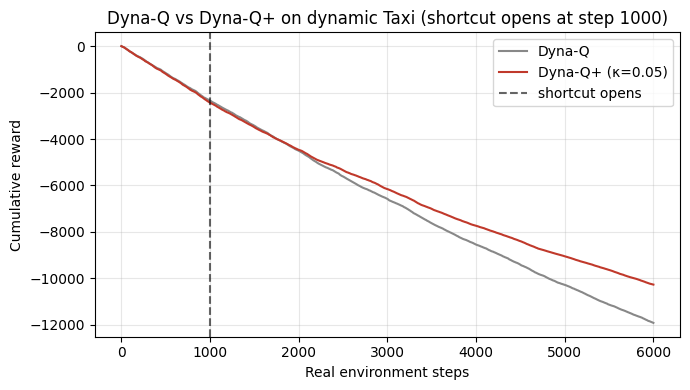

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.cumsum(dq.mean(0)), label="Dyna-Q", color="#888")
ax.plot(np.cumsum(dqp.mean(0)), label="Dyna-Q+ (κ=0.05)", color="#c0392b")
ax.axvline(1000, color="k", ls="--", alpha=0.6, label="shortcut opens")
ax.set_xlabel("Real environment steps")
ax.set_ylabel("Cumulative reward")
ax.set_title("Dyna-Q vs Dyna-Q+ on dynamic Taxi (shortcut opens at step 1000)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("fig4_dyna_plus.png", dpi=140)
plt.show()
